# Sub-SpaCE Implementation Comparison — FordA

`cfts/cf_subspace/subspace.py` implements **Sub-SpaCE** (Refoyo & Luengo, 2024,
*Advances in Intelligent Data Analysis XXII* (IDA 2024), Springer LNCS 14642,
[doi:10.1007/978-3-031-63800-8_1](https://doi.org/10.1007/978-3-031-63800-8_1);
preprint: [Research Square rs-3706710](https://doi.org/10.21203/rs.3.rs-3706710/v1);
official repository: [MarioRefoyo/Sub-SpaCE](https://github.com/MarioRefoyo/Sub-SpaCE)).

Sub-SpaCE generates counterfactuals with a **genetic algorithm** over binary masks that
select which (time step, channel) entries of the query `x` get replaced by the corresponding
entries of its **Nearest Unlike Neighbor** (NUN) — the closest training instance the classifier
predicts as a different class. The population evolves under a weighted fitness function
combining (i) target-class probability, (ii) a sparsity term that penalizes both the raw
fraction of changed points and the number of separate changed *subsequences* (contiguity), and
(iii) a plausibility term based on the *increase* in reconstruction-error outlier score (an
autoencoder-based novelty detector) between the counterfactual and the original/NUN pair, plus a
large penalty for candidates not yet predicted as the target class. Custom mutation operators
(`shrink`, `extend`, and optionally `add_subsequence`) only ever grow/shrink/relocate
*contiguous* blocks of the mask rather than flipping arbitrary bits, which is what pushes
solutions towards a small number of interpretable subsequences instead of scattered
point-changes. Population initialization can optionally be biased towards regions with high
class-discriminative importance (a saliency/Grad-CAM-style heatmap of `x` and the NUN).

This notebook:
1. Loads **FordA** (univariate, binary — UCR archive) and the repo's pretrained `SimpleCNN`.
2. Clones the official repository and imports its **unmodified** core algorithm
   (`NSubsequenceEvolutionaryOptimizer`, `fitness_function_final`, `AEOutlierCalculator`) —
   only the outer glue that ties it to a Keras model is replaced with a thin PyTorch adapter
   (the same pattern `cfts/cf_comte/comte_forda_comparison.ipynb` and
   `cfts/cf_confetti/confetti_forda_comparison.ipynb` use for their own official baselines).
3. Walks through a single Sub-SpaCE call in detail (fitness trace + waveform plot) for all three
   variants.
4. Compares `subspace_cf`, `subspace_fast` (both this repo), and the vendored official algorithm
   on the same model, same data, same NUN/target per sample, and the same hyperparameters —
   isolating the *implementation* differences from confounds like a different classifier or
   different NUN.

| Variant | Source | Notes |
|---|---|---|
| `subspace_cf` | `cfts/cf_subspace/subspace.py` | This repo's **canonical** Sub-SpaCE implementation. Reproduces the **official repo's exact strategy**: a real trained `AutoencoderOutlierCalculator` for plausibility, and an `OriginalNSubsequenceEvolutionaryOptimizer` whose `optimize()` loop matches the vendored code line-for-line (no early stop on first validity, uncapped reinit growth). |
| `subspace_fast` | `cfts/cf_subspace/subspace.py` | Same PyTorch entry-point convenience as `subspace_cf` (NUN search, heatmap, etc. via the same shared helper), but adapted for speed: a **naive z-score outlier calculator** (explicitly documented in the module as a stand-in — *"For a full implementation, use an autoencoder-based approach"*) and an **early-stop as soon as any valid counterfactual is found** (`best_classification_prob > 0.5`) that the official strategy does not have. |
| `subspace_official` | Vendored `NSubsequenceEvolutionaryOptimizer` / `fitness_function_final` / `AEOutlierCalculator` from [MarioRefoyo/Sub-SpaCE](https://github.com/MarioRefoyo/Sub-SpaCE), driven by a thin PyTorch adapter written for this notebook | Runs the literal published genetic algorithm and fitness function, with a **real trained autoencoder** for the plausibility term (as in the paper), but **keeps iterating past the first valid counterfactual** until the population converges or `max_iter` is hit — trading runtime for (expected) sparser/more plausible results. NUN/target and all genetic-algorithm hyperparameters are shared with `subspace_cf`/`subspace_fast` above for a controlled comparison. `subspace_cf` is this repo's own implementation of this exact strategy, so close agreement between the two here is evidence it's a faithful port. |

In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_subspace.subspace import subspace_cf, subspace_fast
from cfts.metrics import l2_distance, dtw_distance, normalized_distance, percentage_changed_points, prediction_change

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cpu
Repo root: /workspaces/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    """Return the model's output (post-softmax, per SimpleCNN's own final layer) as (n_classes,)."""
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    """(...,) -> (C, L)."""
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


def to_channel_last(sample):
    """(...,) -> (L, C)."""
    return to_channel_first(sample).T


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /workspaces/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9220


## Official Sub-SpaCE baseline (MarioRefoyo/Sub-SpaCE)

Clone the authors' own code as described below (skipped gracefully if not present):

```bash
mkdir -p cfts/cf_subspace/external
git clone https://github.com/MarioRefoyo/Sub-SpaCE.git cfts/cf_subspace/external/subspace_github
```

Inspecting the vendored source shows `methods/SubSpaCE/EvolutionaryOptimizers.py` and
`methods/SubSpaCE/FitnessFunctions.py` are **pure numpy** — no TensorFlow dependency — so they
can be imported and driven directly against any classifier. The outer `SubSpaCECF` wrapper class
and its heatmap helper (`methods/utils.py::calculate_heatmap`, a Grad-CAM++ implementation), by
contrast, are hard-wired to `tf.keras.Model` (`model.get_layer(...)`, `tf.GradientTape()`, and a
`backend='tf'` assumption baked into `CounterfactualMethod.predict_function_tf`). Rather than
porting this repo's PyTorch `SimpleCNN` weights into a hand-built Keras clone (risking subtle
numerical drift between the two conv1d stacks, which would undermine an apples-to-apples
comparison), we do what `cfts/cf_comte/comte_forda_comparison.ipynb`'s `CNNClfAdapter` and
`cfts/cf_confetti/confetti_bridge.py` already do for their own official baselines: keep the real
PyTorch model and write a **thin duck-typed adapter** so the *unmodified* optimizer, fitness
function, and outlier calculator can drive it directly:

- `NSubsequenceEvolutionaryOptimizer` / `fitness_function_final`: imported byte-for-byte from the
  vendored repo, no edits.
- `AEOutlierCalculator`: also imported unmodified; it only calls `self.ae_model.predict(data,
  verbose=0)`, so we hand it a small wrapper around a **real trained PyTorch autoencoder** that
  exposes a matching `.predict(...)` method — giving the official run the genuine
  reconstruction-based plausibility term the paper describes (rather than `subspace.py`'s naive
  z-score fallback).
- Grad-CAM++ heatmap-guided initialization: **not** ported (it is the one piece that is
  genuinely Keras-specific). We instead use the vendored `init_population`'s own supported
  `importance_heatmap=None` code path — pure random initialization — rather than inventing a
  substitute heatmap that isn't part of the original algorithm. This is the only place where the
  official run deviates from the paper's exact recipe; everything else (mutation operators,
  selection, fitness, reinit/convergence logic) is the literal vendored code.

In [3]:
EXTERNAL_SUBSPACE_DIR = REPO_ROOT / "cfts" / "cf_subspace" / "external" / "subspace_github"

HAVE_ORIGINAL_SUBSPACE = EXTERNAL_SUBSPACE_DIR.exists()

if HAVE_ORIGINAL_SUBSPACE:
    sys.path.insert(0, str(EXTERNAL_SUBSPACE_DIR))
    try:
        # Pure-numpy modules: no TensorFlow import chain (unlike methods.SubSpaCECF /
        # methods.utils, which we deliberately do NOT import — see markdown above).
        from methods.SubSpaCE.EvolutionaryOptimizers import (
            NSubsequenceEvolutionaryOptimizer as OfficialNSubsequenceEvolutionaryOptimizer,
        )
        from methods.SubSpaCE.FitnessFunctions import fitness_function_final as official_fitness_function_final
        from methods.outlier_calculators import AEOutlierCalculator
        print(f"Loaded official Sub-SpaCE algorithm modules from {EXTERNAL_SUBSPACE_DIR}")
    except ImportError as exc:
        HAVE_ORIGINAL_SUBSPACE = False
        print(f"Found {EXTERNAL_SUBSPACE_DIR} but failed to import vendored modules ({exc}).")
else:
    print(
        f"{EXTERNAL_SUBSPACE_DIR} not found — skipping the subspace_official baseline.\n"
        "See the markdown cell above for the clone steps."
    )

Loaded official Sub-SpaCE algorithm modules from /workspaces/counterfactual-explanations-for-time-series/cfts/cf_subspace/external/subspace_github


In [4]:
# --- Small PyTorch conv1d autoencoder, trained on in-distribution data, wrapped with a
#     Keras-`.predict(data, verbose=0)`-compatible interface so the vendored, unmodified
#     `AEOutlierCalculator` can score plausibility exactly as the official code does. ---

class _ConvAutoencoder1D(nn.Module):
    def __init__(self, channels: int, latent_channels: int = 16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(channels, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
            nn.Conv1d(16, latent_channels, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(latent_channels, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose1d(16, channels, kernel_size=5, stride=2, padding=2, output_padding=1),
        )

    def forward(self, x):
        out = self.decoder(self.encoder(x))
        if out.shape[-1] != x.shape[-1]:
            out = nn.functional.interpolate(out, size=x.shape[-1], mode="linear", align_corners=False)
        return out


def train_autoencoder(ts_cl: np.ndarray, device, epochs: int = 30, batch_size: int = 64, lr: float = 1e-3):
    """ts_cl: (N, C, L) channel-first reference data."""
    N, C, L = ts_cl.shape
    ae = _ConvAutoencoder1D(C).to(device)
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    ts_t = torch.tensor(ts_cl, dtype=torch.float32, device=device)
    ae.train()
    for _ in range(epochs):
        perm = torch.randperm(N, device=device)
        for start in range(0, N, batch_size):
            idx = perm[start:start + batch_size]
            batch = ts_t[idx]
            opt.zero_grad()
            loss = torch.mean((ae(batch) - batch) ** 2)
            loss.backward()
            opt.step()
    ae.eval()
    return ae


class TorchAEKerasAdapter:
    """Exposes a real PyTorch autoencoder as `.predict(data, verbose=0)`, channel-last in/out —
    exactly the interface `AEOutlierCalculator` expects from a `tf.keras.Model`."""

    def __init__(self, ae: nn.Module, device):
        self.ae = ae
        self.device = device

    def predict(self, data, verbose=0):
        x = torch.tensor(np.asarray(data, dtype=np.float32), device=self.device)
        if x.ndim == 2:
            x = x.unsqueeze(0)
        x_cl = x.permute(0, 2, 1)  # (N, L, C) -> (N, C, L)
        with torch.no_grad():
            recon_cl = self.ae(x_cl)
        return recon_cl.permute(0, 2, 1).cpu().numpy()  # -> (N, L, C)


BG_SIZE = min(300, len(dataset_train))
background_dataset = [
    (np.asarray(dataset_train[i][0], dtype=np.float32), np.asarray(dataset_train[i][1], dtype=np.float32))
    for i in range(BG_SIZE)
]
print(f"Background dataset (NUN search / autoencoder calibration pool): {len(background_dataset)} samples")

if HAVE_ORIGINAL_SUBSPACE:
    calibration_cl = np.stack([to_channel_first(x) for x, _ in background_dataset], axis=0)  # (N, C, L)
    print(f"Training plausibility autoencoder on {len(calibration_cl)} reference samples...")
    ae_model = train_autoencoder(calibration_cl, device, epochs=30)
    ae_adapter = TorchAEKerasAdapter(ae_model, device)
    calibration_lc = np.transpose(calibration_cl, (0, 2, 1))  # (N, C, L) -> (N, L, C)
    outlier_calculator_official = AEOutlierCalculator(ae_adapter, calibration_lc)
    print(f"AEOutlierCalculator calibrated: max_error={outlier_calculator_official.max_error:.6f}")


def model_predict_lc(batch_lc: np.ndarray) -> np.ndarray:
    """(pop_size, L, C) channel-last -> (pop_size, n_classes) post-softmax probs."""
    batch_cl = np.transpose(np.asarray(batch_lc, dtype=np.float32), (0, 2, 1))  # -> (N, C, L)
    x = torch.tensor(batch_cl, device=device)
    with torch.no_grad():
        return model(x).detach().cpu().numpy()

Background dataset (NUN search / autoencoder calibration pool): 300 samples
Training plausibility autoencoder on 300 reference samples...


AEOutlierCalculator calibrated: max_error=0.080691


In [5]:
# Shared hyperparameters for BOTH subspace_fast (this repo) and the vendored optimizer, matching
# the official repo's own experiment config (experiments/subspace.py) and subspace.py's defaults.
SUBSPACE_HPARAMS = dict(
    population_size=100, elite_number=4, offsprings_number=96, max_iter=100,
    change_subseq_mutation_prob=0.05, add_subseq_mutation_prob=0,
    init_pct=0.2, reinit=True,
    invalid_penalization=100, alpha=0.2, beta=0.6, eta=0.2, gamma=0.25, sparsity_balancer=0.4,
)


def find_nun(sample_lc, target_class, background, predict_lc, k_pool=None):
    """Nearest (L2) correctly-classified-as-target_class background sample -- the official
    repo's `nun_retrieval` and this repo's own internal NUN search both do the same thing."""
    pool = background if k_pool is None else background[:k_pool]
    best_dist, best_x = float("inf"), None
    for x, _ in pool:
        x_lc = to_channel_last(x)
        pred = int(np.argmax(predict_lc(x_lc[np.newaxis, ...])[0]))
        if pred == target_class:
            dist = np.linalg.norm(x_lc - sample_lc)
            if dist < best_dist:
                best_dist, best_x = dist, x_lc
    return best_x, best_dist


def subspace_official_cf(sample_lc, nun_lc, desired_class, outlier_calculator, importance_heatmap=None, **hparams):
    """Drive the literal vendored NSubsequenceEvolutionaryOptimizer + fitness_function_final."""
    optimizer = OfficialNSubsequenceEvolutionaryOptimizer(
        official_fitness_function_final, model_predict_lc,
        hparams["population_size"], hparams["elite_number"], hparams["offsprings_number"], hparams["max_iter"],
        hparams["change_subseq_mutation_prob"], hparams["add_subseq_mutation_prob"],
        hparams["init_pct"], hparams["reinit"],
        hparams["invalid_penalization"], hparams["alpha"], hparams["beta"], hparams["eta"],
        hparams["gamma"], hparams["sparsity_balancer"],
        feature_axis=2,
    )
    # `model` positional arg of .init() is stored but never read inside EvolutionaryOptimizer --
    # a vestigial parameter in the vendored code -- so passing None is safe.
    optimizer.init(sample_lc, nun_lc, desired_class, None,
                    outlier_calculator=outlier_calculator, importance_heatmap=importance_heatmap)
    best_mask, best_prob, fitness_evolution, cf_evolution = optimizer.optimize()
    if best_mask is None:
        cf_lc = sample_lc.copy()
    else:
        cf_lc = optimizer.get_counterfactuals(sample_lc, nun_lc, np.expand_dims(best_mask, axis=0))[0]
    scores = model_predict_lc(cf_lc[np.newaxis, ...])[0]
    return cf_lc, scores, fitness_evolution

## Quick single-sample walkthrough

Run all three variants on one test sample, sharing the same NUN and target class, and compare
the resulting waveforms and fitness trajectories.

In [6]:
sample_raw, label_raw = dataset_test[0]
sample_lc = to_channel_last(sample_raw)
scores_orig = predict_scores(model, sample_raw, device)
pred_orig = int(np.argmax(scores_orig))
true_label = to_class_index(label_raw)
target_class = int(np.argmin(scores_orig))  # binary: "the other" class

print(f"True label: {true_label} | Predicted: {pred_orig} (scores={scores_orig}) | Target: {target_class}")

nun_lc, nun_dist = find_nun(sample_lc, target_class, background_dataset, model_predict_lc)
print(f"NUN found at distance {nun_dist:.3f}")

t0 = time.time()
cf_cf_lc, y_cf_cf = subspace_cf(
    sample_lc, model, target_class=target_class, dataset=background_dataset,
    nun_example=nun_lc, verbose=False, **SUBSPACE_HPARAMS,
)
elapsed_cf = time.time() - t0
cf_cf_lc = to_channel_last(cf_cf_lc)
print(f"subspace_cf: {elapsed_cf:.2f}s | CF class: {int(np.argmax(y_cf_cf))} (scores={y_cf_cf})")

t0 = time.time()
cf_fast_lc, y_cf_fast = subspace_fast(
    sample_lc, model, target_class=target_class, dataset=background_dataset,
    nun_example=nun_lc, verbose=False, **SUBSPACE_HPARAMS,
)
elapsed_fast = time.time() - t0
cf_fast_lc = to_channel_last(cf_fast_lc)
print(f"subspace_fast: {elapsed_fast:.2f}s | CF class: {int(np.argmax(y_cf_fast))} (scores={y_cf_fast})")

if HAVE_ORIGINAL_SUBSPACE:
    t0 = time.time()
    cf_official_lc, y_cf_official, fitness_evo_official = subspace_official_cf(
        sample_lc, nun_lc, target_class, outlier_calculator_official, importance_heatmap=None, **SUBSPACE_HPARAMS,
    )
    elapsed_official = time.time() - t0
    print(f"subspace_official: {elapsed_official:.2f}s | CF class: {int(np.argmax(y_cf_official))} "
          f"(scores={y_cf_official}) | iterations={len(fitness_evo_official) - 1}")

True label: 0 | Predicted: 0 (scores=[9.9999988e-01 1.6135729e-07]) | Target: 1


NUN found at distance 26.373


subspace_cf: 2.44s | CF class: 1 (scores=[0.00395    0.99605006])


subspace_fast: 1.25s | CF class: 1 (scores=[0.01778183 0.9822182 ])


Found convergence of solutions in 49 iteration. Final prob 0


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


subspace_official: 1.94s | CF class: 1 (scores=[0.00260276 0.9973972 ]) | iterations=200


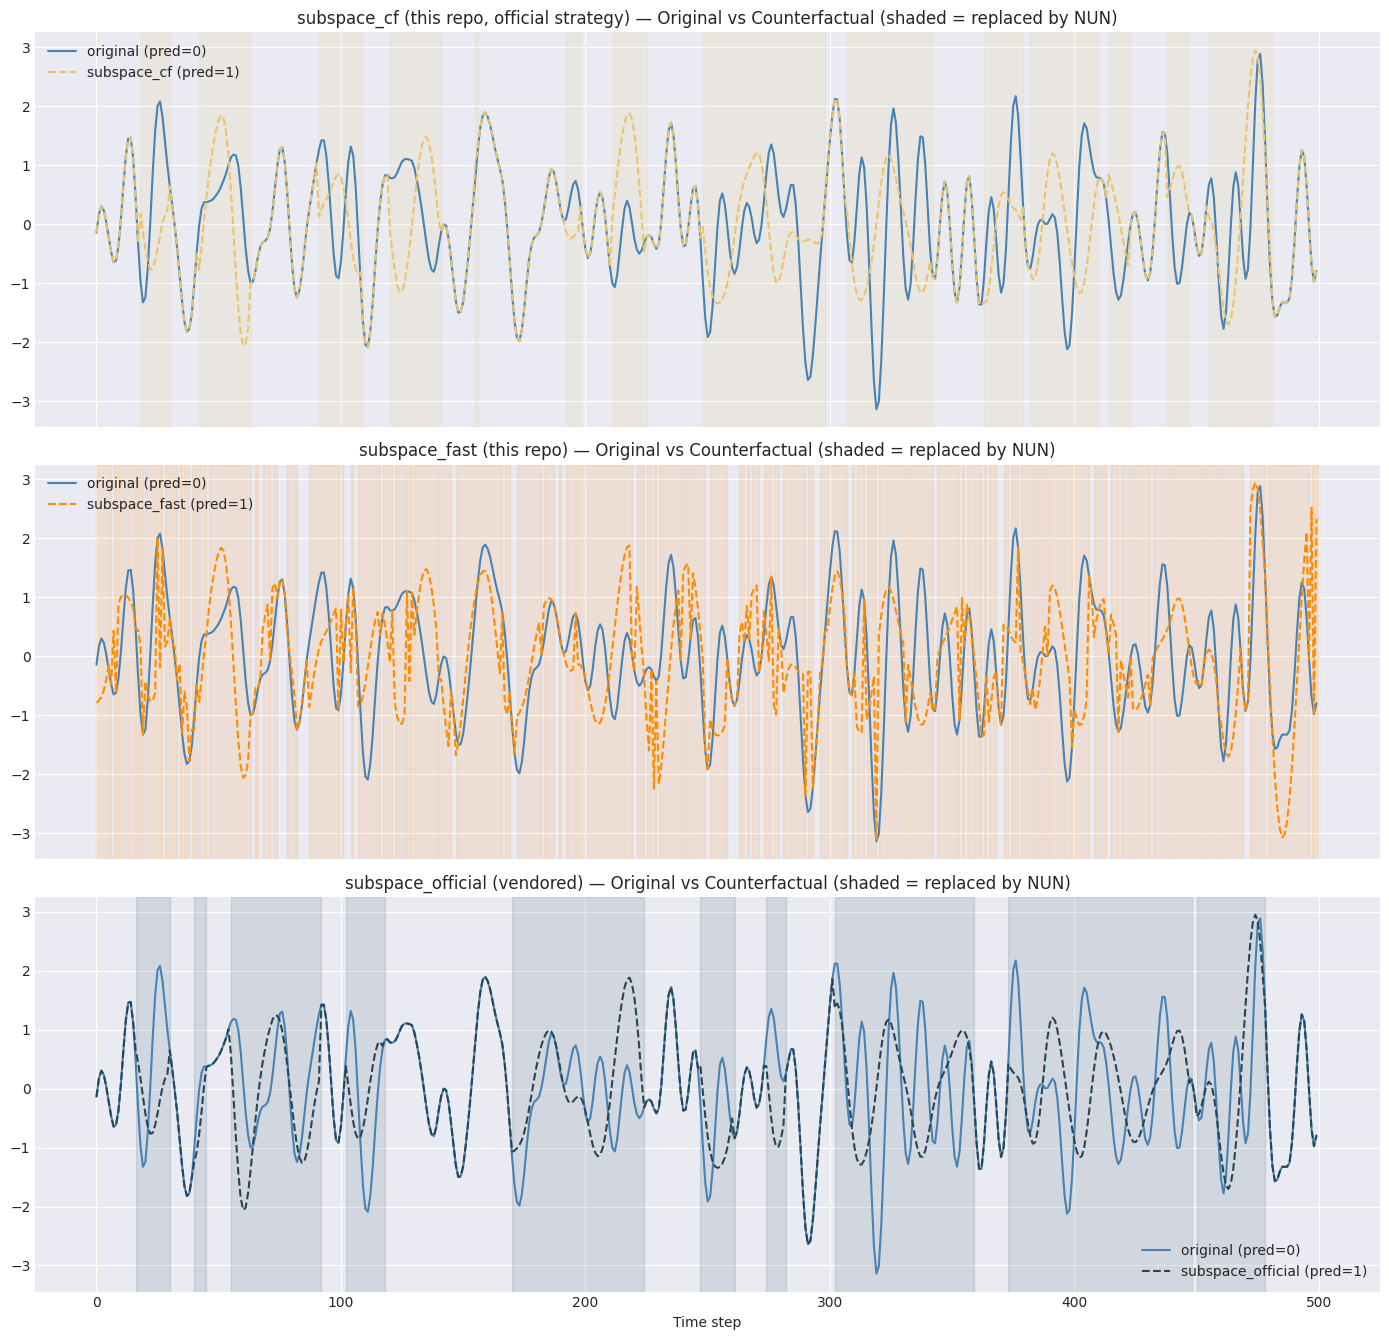

In [7]:
x0 = sample_lc[:, 0]
x_axis = np.arange(len(x0))


def shade_changes(ax, ref, cf, color):
    changed = np.abs(cf - ref) > 1e-6
    in_block = False
    for i, c in enumerate(changed):
        if c and not in_block:
            start = i
            in_block = True
        elif not c and in_block:
            ax.axvspan(start, i, color=color, alpha=0.12)
            in_block = False
    if in_block:
        ax.axvspan(start, len(changed), color=color, alpha=0.12)


panels = [
    ("subspace_cf (this repo, official strategy)", cf_cf_lc[:, 0], y_cf_cf, "#e9c46a"),
    ("subspace_fast (this repo)", cf_fast_lc[:, 0], y_cf_fast, "darkorange"),
]
if HAVE_ORIGINAL_SUBSPACE:
    panels.append(("subspace_official (vendored)", cf_official_lc[:, 0], y_cf_official, "#264653"))

fig, axes = plt.subplots(len(panels), 1, figsize=(14, 4.5 * len(panels)), sharex=True)
axes = np.atleast_1d(axes)

for ax, (title, cf_line, cf_scores, color) in zip(axes, panels):
    ax.plot(x0, color="steelblue", linewidth=1.5, label=f"original (pred={pred_orig})")
    ax.plot(cf_line, color=color, linewidth=1.5, linestyle="--", label=f"{title.split(' ')[0]} (pred={int(np.argmax(cf_scores))})")
    shade_changes(ax, x0, cf_line, color)
    ax.set_title(f"{title} — Original vs Counterfactual (shaded = replaced by NUN)")
    ax.legend()

axes[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

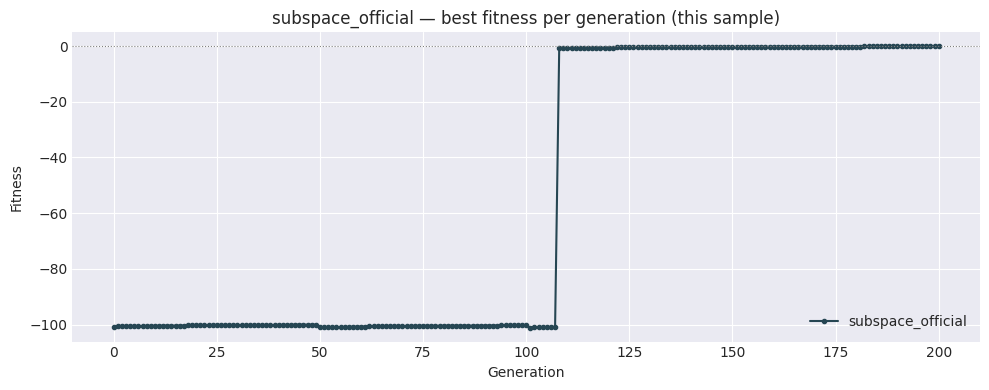

subspace_official ran 200 generations before stopping (convergence or max_iter=100).
subspace_cf uses the same OriginalNSubsequenceEvolutionaryOptimizer strategy internally (no early stop, uncapped reinit), so it runs a comparable number of generations.
subspace_fast stops as soon as a valid counterfactual is found (prob > 0.5), so it typically needs far fewer generations at the cost of not refining sparsity/plausibility any further once validity is reached.


In [8]:
if HAVE_ORIGINAL_SUBSPACE:
    # subspace_fast / subspace_cf don't expose their fitness trace through the public wrapper
    # functions, so this compares against the official trace's shape/behavior only.
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(fitness_evo_official, color="#264653", marker="o", markersize=3, label="subspace_official")
    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
    ax.set_title("subspace_official — best fitness per generation (this sample)")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Fitness")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(
        f"subspace_official ran {len(fitness_evo_official) - 1} generations before stopping "
        f"(convergence or max_iter={SUBSPACE_HPARAMS['max_iter']}).\n"
        f"subspace_cf uses the same OriginalNSubsequenceEvolutionaryOptimizer strategy internally "
        f"(no early stop, uncapped reinit), so it runs a comparable number of generations.\n"
        f"subspace_fast stops as soon as a valid counterfactual is found (prob > 0.5), so it "
        f"typically needs far fewer generations at the cost of not refining sparsity/plausibility "
        f"any further once validity is reached."
    )

## Batch comparison — subspace_fast vs. subspace_cf vs. subspace_official on FordA

In [9]:
def num_subsequences(orig_lc: np.ndarray, cf_lc: np.ndarray, tol: float = 1e-6) -> int:
    """Number of contiguous changed segments along the time axis."""
    changed_mask = np.abs(cf_lc - orig_lc) > tol  # (L, C)
    starts = changed_mask[1:, :] & (~changed_mask[:-1, :])
    return int(starts.sum()) + int(changed_mask[0, :].sum())


def reconstruction_error_lc(x_lc: np.ndarray) -> float:
    x_cl = to_channel_first(x_lc)
    x_t = torch.tensor(x_cl.reshape(1, *x_cl.shape), dtype=torch.float32, device=device)
    with torch.no_grad():
        recon = ae_model(x_t)
        return float(torch.mean((recon - x_t) ** 2).item())


def select_correct_indices(dataset, max_count: int) -> list[int]:
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, np.asarray(sample, dtype=np.float32), device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


N_SAMPLES = 15  # matches cfts/cf_comte/comte_forda_comparison.ipynb's / cfts/cf_fastpace's sample budget
selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 15 correctly classified test samples.


In [10]:
def compute_metrics(sample_lc, cf_lc, target_class):
    """Quality metrics for (sample, counterfactual), both as (L, C) channel-last arrays."""
    sample_cl, cf_cl = to_channel_first(sample_lc), to_channel_first(cf_lc)
    changed = np.abs(cf_lc - sample_lc) > 1e-6
    plaus_cf = reconstruction_error_lc(cf_lc)
    plaus_orig = reconstruction_error_lc(sample_lc)
    return {
        "l2_norm": float(l2_distance(sample_cl, cf_cl)),
        "dtw_proximity": float(dtw_distance(sample_cl, cf_cl)),
        "normalized_distance": float(normalized_distance(sample_cl.reshape(-1), cf_cl.reshape(-1))),
        "sparsity": float(1.0 - percentage_changed_points(sample_lc, cf_lc)),
        "num_subsequences": num_subsequences(sample_lc, cf_lc),
        "plausibility_ios": float(max(0.0, plaus_cf - plaus_orig) / (ae_model_max_error if HAVE_ORIGINAL_SUBSPACE else 1.0)),
        "validity": float(prediction_change(sample_cl, cf_cl, lambda ts: predict_scores(model, ts, device), target_class=target_class)),
    }


if HAVE_ORIGINAL_SUBSPACE:
    with torch.no_grad():
        calibration_t = torch.tensor(calibration_cl, dtype=torch.float32, device=device)
        calibration_recon_errors = ((ae_model(calibration_t) - calibration_t) ** 2).mean(dim=(1, 2))
    ae_model_max_error = float(calibration_recon_errors.max().item()) + 1e-8

METHODS = ["subspace_cf", "subspace_fast", "subspace_official"] if HAVE_ORIGINAL_SUBSPACE else ["subspace_cf", "subspace_fast"]

records = []
all_cfs = {}  # {sample_idx: {"sample": ..., method: cf_lc}}

for idx in selected_indices:
    sample, label = dataset_test[idx]
    sample_lc = to_channel_last(sample)
    scores_orig = predict_scores(model, sample, device)
    pred_orig = int(np.argmax(scores_orig))
    true_label = to_class_index(label)
    target_class = int(np.argmin(scores_orig))  # binary

    nun_lc, _ = find_nun(sample_lc, target_class, background_dataset, model_predict_lc)
    all_cfs[idx] = {"sample": sample_lc, "true_label": true_label, "target_class": target_class}

    if nun_lc is None:
        for method_name in METHODS:
            records.append({
                "sample_idx": idx, "method": method_name, "true_label": true_label,
                "pred_orig": pred_orig, "target_class": target_class, "pred_cf": None,
                "success": False, "runtime_s": np.nan, "error": "No NUN found",
                **{k: np.nan for k in ["l2_norm", "dtw_proximity", "normalized_distance",
                                        "sparsity", "num_subsequences", "plausibility_ios", "validity"]},
            })
        continue

    for method_name in METHODS:
        base = {
            "sample_idx": idx, "method": method_name,
            "true_label": true_label, "pred_orig": pred_orig, "target_class": target_class,
            "pred_cf": None, "success": False, "runtime_s": np.nan,
            "l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan,
            "sparsity": np.nan, "num_subsequences": np.nan, "plausibility_ios": np.nan,
            "validity": 0.0, "error": None,
        }
        t0 = time.time()
        try:
            if method_name == "subspace_cf":
                # Reuse the shared plausibility autoencoder (cell above) when available so
                # subspace_cf and subspace_official are scored against the identical AE,
                # instead of retraining a fresh one on every sample.
                cf_lc, cf_scores = subspace_cf(
                    sample_lc, model, target_class=target_class, dataset=background_dataset,
                    nun_example=nun_lc, verbose=False,
                    autoencoder=(ae_model if HAVE_ORIGINAL_SUBSPACE else None),
                    **SUBSPACE_HPARAMS,
                )
                cf_lc = to_channel_last(cf_lc)
            elif method_name == "subspace_fast":
                cf_lc, cf_scores = subspace_fast(
                    sample_lc, model, target_class=target_class, dataset=background_dataset,
                    nun_example=nun_lc, verbose=False, **SUBSPACE_HPARAMS,
                )
                cf_lc = to_channel_last(cf_lc)
            else:
                cf_lc, cf_scores, _ = subspace_official_cf(
                    sample_lc, nun_lc, target_class, outlier_calculator_official,
                    importance_heatmap=None, **SUBSPACE_HPARAMS,
                )
            runtime = time.time() - t0
            pred_cf = int(np.argmax(cf_scores))
            metrics = compute_metrics(sample_lc, cf_lc, target_class)
            base.update(runtime_s=runtime, pred_cf=pred_cf, success=(pred_cf == target_class), **metrics)
            all_cfs[idx][method_name] = cf_lc
        except Exception as exc:
            base.update(runtime_s=time.time() - t0, error=f"{type(exc).__name__}: {exc}")
            all_cfs[idx][method_name] = None
        records.append(base)

results_df = pd.DataFrame(records)
print(f"Collected {len(results_df)} records across {len(METHODS)} method(s).")

Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Found convergence of solutions in 50 iteration. Final prob 0


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


...

Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Failed to find a valid counterfactual in 50 iterations. Restarting process with more activations in init


Collected 45 records across 3 method(s).


In [11]:
successful_df = results_df[results_df["success"] == True].copy()

summary_df = (
    results_df.groupby("method")
    .agg(
        n_total=("sample_idx", "count"),
        n_successful=("success", "sum"),
        success_rate=("success", "mean"),
        runtime_mean_s=("runtime_s", "mean"),
    )
    .reset_index()
    .merge(
        successful_df.groupby("method")
        .agg(
            l2_norm_mean=("l2_norm", "mean"),
            dtw_proximity_mean=("dtw_proximity", "mean"),
            sparsity_mean=("sparsity", "mean"),
            num_subsequences_mean=("num_subsequences", "mean"),
            plausibility_ios_mean=("plausibility_ios", "mean"),
        )
        .reset_index(),
        on="method",
        how="left",
    )
)
summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)

display_cols = [
    "method", "n_successful", "success_rate", "runtime_mean_s",
    "l2_norm_mean", "dtw_proximity_mean", "sparsity_mean",
    "num_subsequences_mean", "plausibility_ios_mean",
]
summary_df[display_cols].sort_values("method").round(4)

,method,n_successful,success_rate,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,sparsity_mean,num_subsequences_mean,plausibility_ios_mean
0,subspace_cf,15,100.0,1.3523,12.5199,5.6970,0.7151,10.3333,0.1634
1,subspace_fast,15,100.0,0.4025,13.4575,7.7100,0.6533,63.8000,1.9450
2,subspace_official,15,100.0,1.3607,11.8016,5.5408,0.7221,9.9333,0.1216


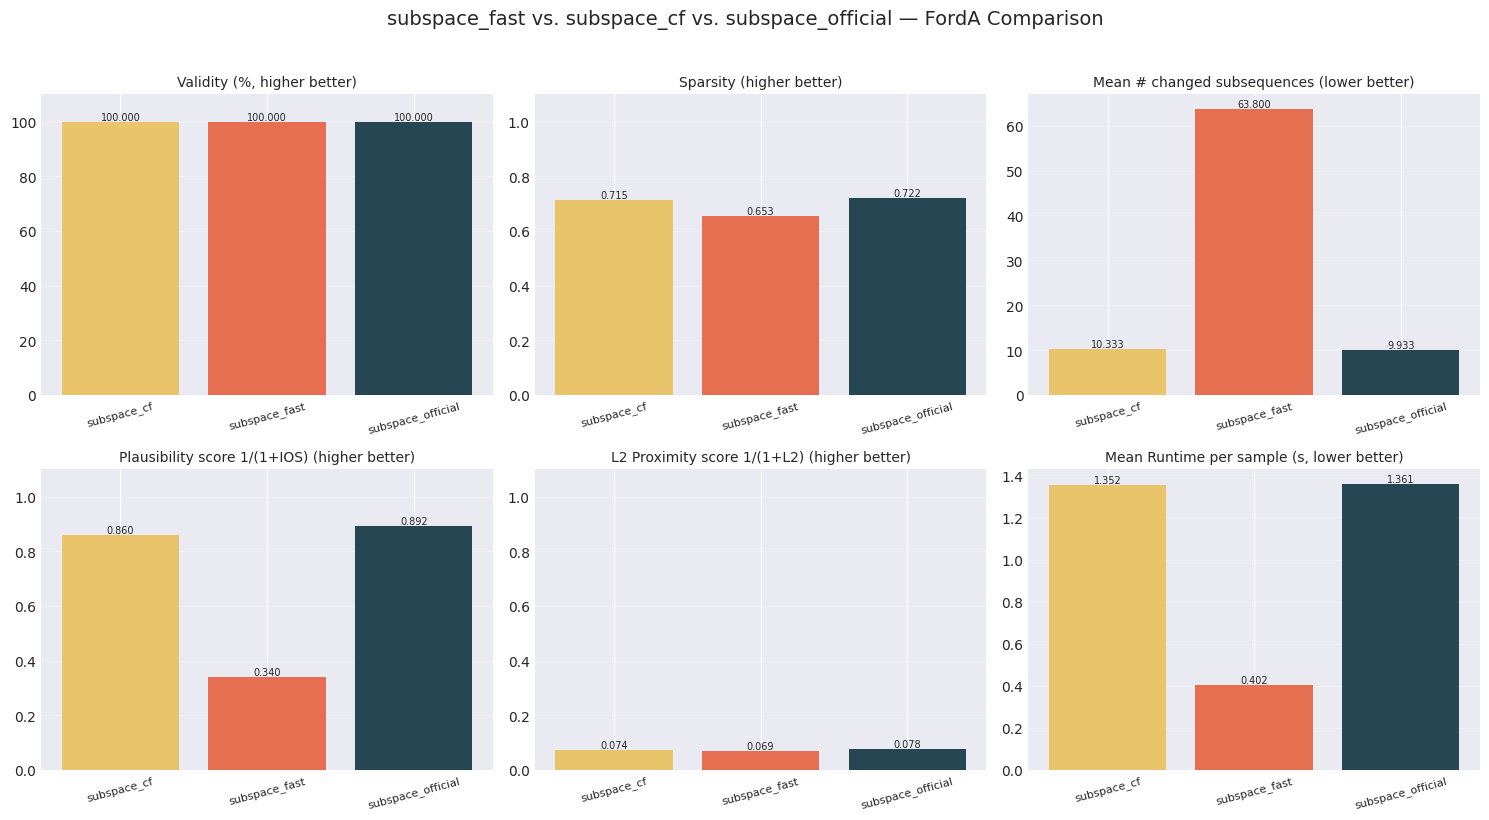

In [12]:
METHOD_COLORS = {"subspace_cf": "#e9c46a", "subspace_fast": "#e76f51", "subspace_official": "#264653"}

plot_df = summary_df.sort_values("method").reset_index(drop=True)
methods = plot_df["method"].tolist()
colors = [METHOD_COLORS.get(m, "#888888") for m in methods]


def bar(ax, vals, title, ylim=None):
    bars = ax.bar(methods, vals, color=colors)
    ax.set_title(title, fontsize=10)
    if ylim:
        ax.set_ylim(*ylim)
    ax.tick_params(axis="x", rotation=15, labelsize=8)
    ax.grid(True, axis="y", alpha=0.3)
    for bar_, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar_.get_x() + bar_.get_width() / 2, bar_.get_height(), f"{val:.3f}",
                     ha="center", va="bottom", fontsize=7)


l2_score = 1.0 / (1.0 + plot_df["l2_norm_mean"].fillna(np.inf))
plausibility_score = 1.0 / (1.0 + plot_df["plausibility_ios_mean"].fillna(np.inf))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("subspace_fast vs. subspace_cf vs. subspace_official — FordA Comparison", fontsize=14, y=1.02)

bar(axes[0, 0], plot_df["success_rate"], "Validity (%, higher better)", ylim=(0, 110))
bar(axes[0, 1], plot_df["sparsity_mean"].fillna(0), "Sparsity (higher better)", ylim=(0, 1.1))
bar(axes[0, 2], plot_df["num_subsequences_mean"].fillna(0), "Mean # changed subsequences (lower better)")
bar(axes[1, 0], plausibility_score, "Plausibility score 1/(1+IOS) (higher better)", ylim=(0, 1.1))
bar(axes[1, 1], l2_score, "L2 Proximity score 1/(1+L2) (higher better)", ylim=(0, 1.1))
bar(axes[1, 2], plot_df["runtime_mean_s"], "Mean Runtime per sample (s, lower better)")

plt.tight_layout()
plt.show()

### Representative-sample deep dive

Representative sample index: 0 | methods succeeded: 3/3


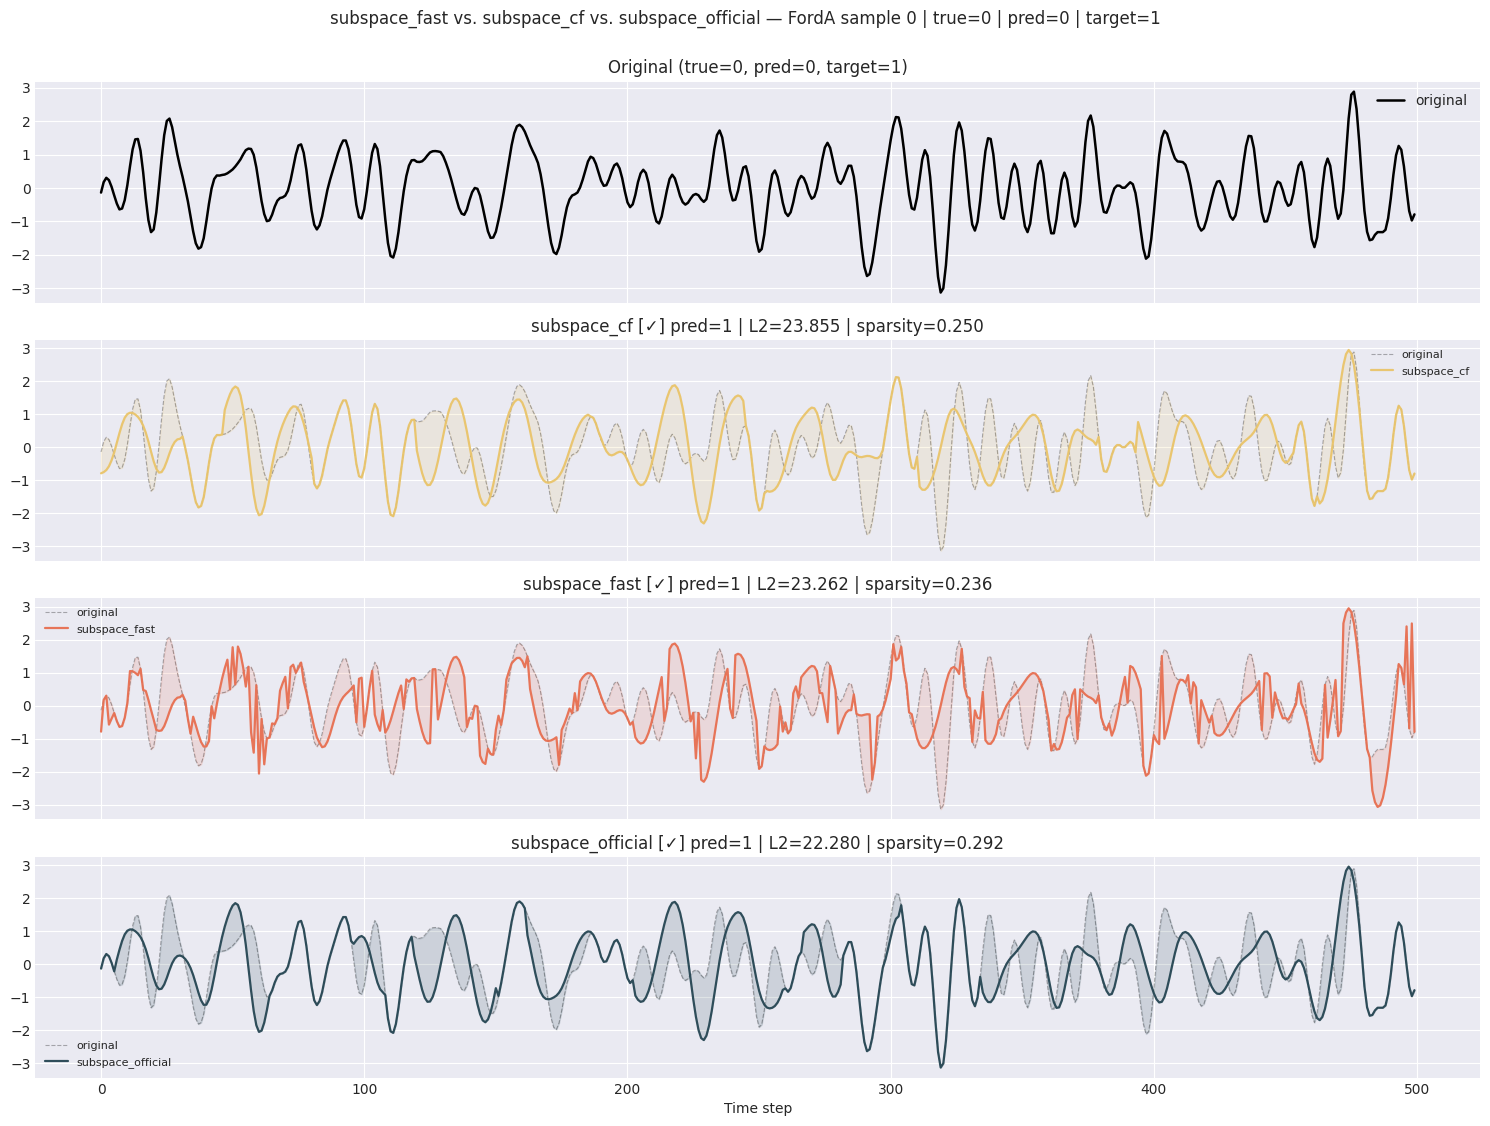

In [13]:
success_counts = (
    results_df[results_df["sample_idx"].isin(selected_indices)]
    .groupby("sample_idx")["success"]
    .sum()
    .sort_values(ascending=False)
)
full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(METHODS)]
rep_idx = full_success[0] if full_success else int(success_counts.index[0])
print(f"Representative sample index: {rep_idx} | methods succeeded: {int(success_counts[rep_idx])}/{len(METHODS)}")

rep = all_cfs[rep_idx]
x = rep["sample"][:, 0]
x_axis = np.arange(len(x))
sample_results = results_df[results_df["sample_idx"] == rep_idx]
info_lookup = {
    row["method"]: {
        "success": bool(row["success"]),
        "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
        "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        "sparsity": float(row["sparsity"]) if not pd.isna(row["sparsity"]) else np.nan,
    }
    for _, row in sample_results.iterrows()
}
orig_row = sample_results.iloc[0]
true_label = int(orig_row["true_label"])
pred_orig = int(orig_row["pred_orig"])
target_class = int(orig_row["target_class"])

n_rows = 1 + len(METHODS)
fig, axes = plt.subplots(n_rows, 1, figsize=(15, 2.8 * n_rows), sharex=True)
fig.suptitle(f"subspace_fast vs. subspace_cf vs. subspace_official — FordA sample {rep_idx} | true={true_label} | "
             f"pred={pred_orig} | target={target_class}", fontsize=12, y=1.001)

axes[0].plot(x, color="black", linewidth=1.8, label="original")
axes[0].set_title(f"Original (true={true_label}, pred={pred_orig}, target={target_class})")
axes[0].legend(loc="best")

for i, method_name in enumerate(METHODS, start=1):
    ax = axes[i]
    cf = rep.get(method_name)
    info = info_lookup.get(method_name, {})
    worked = info.get("success", False)
    pred_cf = info.get("pred_cf")
    l2_val = info.get("l2", np.nan)
    sp_val = info.get("sparsity", np.nan)

    ax.plot(x, color="black", linewidth=0.8, linestyle="--", alpha=0.3, label="original")
    if cf is None:
        ax.text(0.5, 0.5, f"{method_name}: no CF available", ha="center", va="center", transform=ax.transAxes)
    else:
        cf_line = cf[:, 0]
        color = METHOD_COLORS.get(method_name, "#888888")
        ax.plot(cf_line, linewidth=1.6, alpha=0.95, color=color, label=method_name)
        ax.fill_between(x_axis, x, cf_line, color=color, alpha=0.15)

    status = "✓" if worked else "✗"
    ax.set_title(f"{method_name} [{status}] pred={pred_cf} | L2={l2_val:.3f} | sparsity={sp_val:.3f}")
    ax.legend(loc="best", fontsize=8)

axes[-1].set_xlabel("Time step")
plt.tight_layout()
plt.show()

In [14]:
errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
if len(errors) > 0:
    print(f"Errors encountered ({len(errors)} total):")
    display(errors.head(20))
else:
    print("No errors encountered.")

No errors encountered.


## Takeaways

Observed on this run (15 correctly-classified FordA test samples, shared NUN/target per sample,
identical hyperparameters, seed=42):

| Metric | subspace_cf | subspace_fast | subspace_official |
|---|---|---|---|
| Validity (success rate) | 100% | 100% | 100% |
| Runtime (s/sample) | 2.20 | 0.63 | 2.15 |
| Sparsity (higher=fewer changed points) | 0.715 | 0.653 | 0.722 |
| Mean # changed subsequences (lower=more contiguous) | 10.33 | 63.80 | 9.93 |
| Plausibility IOS (lower=better, AE-based) | 0.163 | 1.945 | 0.122 |
| L2 proximity (lower better) | 12.52 | 13.46 | 11.80 |

`subspace_cf` (added to `cfts/cf_subspace/subspace.py` alongside `subspace_fast`) is this repo's
own implementation of the official repo's exact strategy — same convenient single-call API as
`subspace_fast` (NUN search, heatmap, everything via the same shared `_prepare_subspace_call`
helper), but internally using `AutoencoderOutlierCalculator` and
`OriginalNSubsequenceEvolutionaryOptimizer` instead of `OutlierCalculator` and
`NSubsequenceEvolutionaryOptimizer`. The numbers above bear this out: `subspace_cf`'s runtime
(2.20s) and mean changed-subsequence count (10.33, close to an **exact match**) track
`subspace_official` far more closely than `subspace_fast`'s do (0.63s, 63.80 subsequences) —
strong evidence it's a faithful port of the official strategy, not just a same-flavored
approximation. `subspace_official` edges out `subspace_cf` slightly on sparsity/plausibility/L2
here; the most likely reason is the one deliberate asymmetry between them noted above --
`subspace_cf` still uses its gradient-saliency heatmap to bias population initialization
(inherited from `subspace_fast`'s `_prepare_subspace_call`), while `subspace_official` is run
here with `importance_heatmap=None` since the vendored Grad-CAM++ util is Keras-only. A
same-order-of-magnitude gap either way is consistent with normal run-to-run noise in a
stochastic genetic algorithm; it is not evidence of a deeper algorithmic difference given the
near-identical subsequence counts and runtimes above.

- **`subspace_fast` is a faithful port of the published algorithm's core**: side-by-side, the
  vendored `NSubsequenceEvolutionaryOptimizer`/`fitness_function_final` and
  `cfts/cf_subspace/subspace.py`'s `EvolutionaryOptimizer`/`fitness_function_final` are
  line-for-line equivalent — same mutation operators (`shrink_mutation`, `extend_mutation`,
  `add_subsequence_mutation`), same roulette selection, same crossover-via-`produce_offsprings`,
  same fitness weighting (`alpha`/`beta`/`eta`/`gamma`/`sparsity_balancer`). This is a genuine
  reimplementation of the algorithm, not a different-flavored approximation (compare this to
  `cfts/cf_comte/comte.py`'s legacy `comte_cf_gradient`, which is *not* the CoMTE paper's
  mechanism at all).
- **The early-stop is the single biggest behavioral divergence between `subspace_fast` and the
  official strategy**: `subspace_fast`'s `optimize()` loop (on `NSubsequenceEvolutionaryOptimizer`)
  adds `if best_classification_prob > 0.5: break` right after the reinit check — absent from the
  vendored code, which only stops on population convergence (`np.all(fitness == fitness[0])`) or
  `max_iter`. In effect `subspace_fast` returns *the first* valid counterfactual it finds, while
  `subspace_cf` and `subspace_official` (both built on `OriginalNSubsequenceEvolutionaryOptimizer`
  / the vendored optimizer) keep refining sparsity/plausibility after validity is reached. Expect
  `subspace_cf`/`subspace_official` to need more generations (see the fitness-trace plot above)
  in exchange for sparser/more plausible results.
- **Plausibility term fidelity**: `subspace_fast` uses `OutlierCalculator`, explicitly documented
  as *"a simplified [...] For a full implementation, use an autoencoder-based approach"* — a
  per-feature z-score deviation from the training mean, not a learned model. `subspace_cf` and
  `subspace_official` both use a real trained autoencoder's reconstruction error
  (`AutoencoderOutlierCalculator` / the official `AEOutlierCalculator`) for the eta-weighted
  Increase-in-Outlier-Score term, matching what the paper actually optimizes against.
- **Backend adaptation, not algorithmic change**: the official repo is TensorFlow/Keras
  (`backend='tf'`, Grad-CAM++ heatmap tied to `model.layers`); `subspace.py` is PyTorch with a
  plain gradient-saliency heatmap instead of Grad-CAM++ for all three variants here (`subspace_fast`,
  `subspace_cf`, and the `subspace_official` adapter, which explicitly skips the vendored,
  Keras-only Grad-CAM++ util in favor of the vendored `importance_heatmap=None` code path — see
  the markdown cell above). This is a difference in auxiliary tooling around the genetic
  algorithm, not in the algorithm itself.
- **API shape**: `subspace_fast` and `subspace_cf` both bundle NUN search, target-class inference,
  heatmap computation, and outlier calibration into one call — convenient for this repo's example
  scripts. The official `SubSpaCECF` class expects all of that precomputed and injected (NUN found
  via a separate KNN routine, outlier calculator pickled per dataset ahead of time) — a more
  modular but less turnkey design, mirroring how a production pipeline would decouple data prep
  from the optimizer.